# Day 7: LanceDB

LanceDB is an open-source vector database built on Lance, a columnar storage format designed for AI workloads. It is the final chapter of this book for a deliberate reason: LanceDB sits furthest along the spectrum from pure library to full database, and it solves a problem none of the previous six tools address - what happens when your dataset does not fit in RAM?

Every library and database we have used so far - FAISS, Voyager, PyNNDescent, USearch, sklearn and Chroma - loads indexes and vectors into memory. LanceDB stores data on disk in the Lance columnar format and queries it without loading everything into RAM. This makes it the natural choice for datasets that are too large for available memory, while still supporting vector search, metadata filtering and SQL-style queries through DuckDB integration.

## When would you reach for LanceDB?

LanceDB is the right choice when:

- Your dataset does not fit in RAM - LanceDB queries disk-resident data efficiently
- You need SQL-style analytics alongside vector search - DuckDB integration gives you full SQL over your vector store
- You want versioned data with Git-style branching - Lance format supports time travel and rollback
- You need tight integration with the Arrow and pandas ecosystem
- You want a zero-server embedded database that scales to cloud storage (S3, GCS) without code changes

## The use case

We load the full Nordvik crime dataset into LanceDB, build a vector index and demonstrate the features that distinguish it from everything that came before: disk-based storage, SQL analytics via DuckDB, metadata filtering and a final comparison across all seven days.

## 1. Install Dependencies

In [1]:
%pip install lancedb==0.33.0 \
             numpy==2.2.6 \
             pandas==3.0.3 \
             plotly==6.9.0 \
             pyarrow==25.0.0 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import lancedb
import numpy as np
import os
import pandas as pd
import pyarrow as pa
import plotly.graph_objects as go
import time

from tqdm.notebook import tqdm

print(f"OK  LanceDB version: {lancedb.__version__}")

OK  LanceDB version: 0.33.0


## 3. Load Data and Embeddings

In [3]:
df         = pd.read_parquet("data/nordvik_crimes.parquet")
embeddings = np.load("data/nordvik_embeddings.npy").astype("float32")
ids        = np.loadtxt("data/nordvik_ids.txt", dtype = str, encoding = "utf-8")

ground_truth   = np.load("data/nordvik_ground_truth.npy")
sample_indices = np.load("data/nordvik_ground_truth_indices.npy")
query_sample   = embeddings[sample_indices]

DIM = embeddings.shape[1]
K   = 10

print(f"OK  Dataset:      {len(df):,} rows")
print(f"OK  Embeddings:   {embeddings.shape} {embeddings.dtype}")
print(f"OK  Ground truth: {ground_truth.shape} ({len(sample_indices):,} sampled queries)")
print(f"OK  Dimensions:   {DIM}")

OK  Dataset:      500,000 rows
OK  Embeddings:   (500000, 384) float32
OK  Ground truth: (1000, 10) (1,000 sampled queries)
OK  Dimensions:   384


## 4. Create a LanceDB Database and Table

LanceDB connects to a local directory - no server, no port, no configuration file. The database is the directory. We build a PyArrow schema that includes the vector column alongside all structured fields, then add data in batches.

In [4]:
LANCE_PATH = "data/nordvik_lance"
TABLE_NAME = "crimes"

db = lancedb.connect(LANCE_PATH)

# Drop table if it exists
if TABLE_NAME in db.list_tables():
    db.drop_table(TABLE_NAME)
    print("OK  Existing table dropped")

# Define schema
schema = pa.schema([
    pa.field("IncidentID",     pa.string()),
    pa.field("CrimeType",      pa.string()),
    pa.field("CrimeSubType",   pa.string()),
    pa.field("Neighborhood",   pa.string()),
    pa.field("PropertyType",   pa.string()),
    pa.field("Latitude",       pa.float64()),
    pa.field("Longitude",      pa.float64()),
    pa.field("DateTime",       pa.string()),
    pa.field("Weapon",         pa.string()),
    pa.field("PropertyStolen", pa.string()),
    pa.field("MO_TEXT",        pa.string()),
    pa.field("vector",         pa.list_(pa.float32(), DIM)),
])

print(f"OK  Connected to LanceDB at {LANCE_PATH}")
print(f"    Schema defined with {len(schema)} fields including vector column")

OK  Connected to LanceDB at data/nordvik_lance
    Schema defined with 12 fields including vector column


In [5]:
BATCH_SIZE = 10_000
n_batches  = (len(df) + BATCH_SIZE - 1) // BATCH_SIZE
table      = None

print(f"OK  Adding {len(df):,} rows in batches of {BATCH_SIZE:,}...")
start = time.perf_counter()

for batch_num in tqdm(range(n_batches), desc = "Adding to LanceDB"):
    s = batch_num * BATCH_SIZE
    e = min(s + BATCH_SIZE, len(df))
    batch_df = df.iloc[s:e].copy()
    batch_df["vector"] = [embeddings[i].tolist() for i in range(s, e)]

    batch_arrow = pa.Table.from_pandas(
        batch_df[["IncidentID", "CrimeType", "CrimeSubType", "Neighborhood",
                  "PropertyType", "Latitude", "Longitude", "DateTime",
                  "Weapon", "PropertyStolen", "MO_TEXT", "vector"]],
        schema = schema,
    )

    if table is None:
        table = db.create_table(TABLE_NAME, data = batch_arrow, mode = "overwrite")
    else:
        table.add(batch_arrow)

elapsed = time.perf_counter() - start
print(f"\nOK  All rows added ({elapsed:.1f}s)")
print(f"    Row count: {table.count_rows():,}")

# Show disk usage
size_mb = sum(
    os.path.getsize(os.path.join(root, f))
    for root, dirs, files in os.walk(LANCE_PATH)
    for f in files
) / 1024 / 1024
print(f"    Disk usage: {size_mb:.1f} MB")

OK  Adding 500,000 rows in batches of 10,000...


Adding to LanceDB:   0%|          | 0/50 [00:00<?, ?it/s]


OK  All rows added (7.1s)
    Row count: 500,000
    Disk usage: 3406.7 MB


## 5. Build the Vector Index

LanceDB separates data ingestion from index building. We first add all data, then build an IVF-PQ (Inverted File with Product Quantization) index. Product quantization compresses vectors to a fraction of their original size, which is how LanceDB keeps memory usage low even on large datasets.

In [6]:
print("OK  Building IVF-PQ vector index...")
start = time.perf_counter()

table.create_index(
    metric = "cosine",
    num_partitions = 256,
    num_sub_vectors = 96,
    vector_column_name = "vector",
)

build_time = time.perf_counter() - start
print(f"OK  Index built ({build_time:.1f}s)")
print(f"    num_partitions=256, num_sub_vectors=96")

size_mb = sum(
    os.path.getsize(os.path.join(root, f))
    for root, dirs, files in os.walk(LANCE_PATH)
    for f in files
) / 1024 / 1024
print(f"    Disk usage after index: {size_mb:.1f} MB")

OK  Building IVF-PQ vector index...
OK  Index built (42.8s)
    num_partitions=256, num_sub_vectors=96
    Disk usage after index: 3455.7 MB


## 6. Basic Vector Search

In [7]:
QUERY_IDX = df[df["CrimeType"] == "Burglary"].index[0]
query_vec = embeddings[QUERY_IDX].tolist()

print(f"Query incident: {df['IncidentID'].iloc[QUERY_IDX]}")
print(f"Crime type:     {df['CrimeType'].iloc[QUERY_IDX]}")
print(f"MO_TEXT:        {df['MO_TEXT'].iloc[QUERY_IDX]}")
print()

N_REPEATS = 50
times     = []

for _ in range(N_REPEATS):
    start = time.perf_counter()
    results = (
        table.search(query_vec)
             .limit(K)
             .select(["IncidentID", "CrimeType", "MO_TEXT", "_distance"])
             .to_pandas()
    )
    times.append((time.perf_counter() - start) * 1000)

latency = float(np.mean(times))

print(f"OK  Query complete ({latency:.3f}ms avg over {N_REPEATS} runs)\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (_, row) in enumerate(results.iterrows(), 1):
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {abs(row['_distance']):<10.4f} {row['MO_TEXT'][:60]}...")

Query incident: NVK-000004
Crime type:     Burglary
MO_TEXT:        At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

OK  Query complete (3.559ms avg over 50 runs)

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0365     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.2694     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-071545     Burglary         0.2734     Residence - Single Family in Hartley Cross targeted. Items r...
4      NVK-487821     Burglary         0.3048     Multiple offenders described as medium build, tall, wearing ...
5      NVK-090521     Burglary         0.3093     Multiple offenders descri

## 7. Metadata Filtering

LanceDB supports SQL-style `where` clauses alongside vector search. Unlike Chroma's dictionary-based filter syntax, LanceDB filters are plain SQL strings - a natural fit for anyone familiar with databases.

In [8]:
# Filter 1 - burglary only
results_burglary = (
    table.search(query_vec)
         .where("CrimeType = 'Burglary'")
         .limit(K)
         .select(["IncidentID", "CrimeType", "Neighborhood", "_distance"])
         .to_pandas()
)

print("Results filtered to Burglary only:\n")
for rank, (_, row) in enumerate(results_burglary.iterrows(), 1):
    print(f"  {rank}. {row['IncidentID']} [{row['CrimeType']}] [{row['Neighborhood']}] dist={abs(row['_distance']):.4f}")

Results filtered to Burglary only:

  1. NVK-000004 [Burglary] [Hartley Cross] dist=0.0365
  2. NVK-429593 [Burglary] [Hartley Cross] dist=0.2694
  3. NVK-071545 [Burglary] [Hartley Cross] dist=0.2734
  4. NVK-487821 [Burglary] [Hartley Cross] dist=0.3048
  5. NVK-090521 [Burglary] [Hartley Cross] dist=0.3093
  6. NVK-059565 [Burglary] [Hartley Cross] dist=0.3111
  7. NVK-421978 [Burglary] [Hartley Cross] dist=0.3139
  8. NVK-123098 [Burglary] [Hartley Cross] dist=0.3147
  9. NVK-113626 [Burglary] [Hartley Cross] dist=0.3215
  10. NVK-295844 [Burglary] [Hartley Cross] dist=0.3233


In [9]:
# Filter 2 - armed incidents only
results_armed = (
    table.search(query_vec)
         .where("Weapon != 'none'")
         .limit(K)
         .select(["IncidentID", "CrimeType", "Weapon", "_distance"])
         .to_pandas()
)

print("Results filtered to armed incidents only:\n")
for rank, (_, row) in enumerate(results_armed.iterrows(), 1):
    print(f"  {rank}. {row['IncidentID']} [{row['CrimeType']}] weapon={row['Weapon']} dist={abs(row['_distance']):.4f}")

Results filtered to armed incidents only:

  1. NVK-487821 [Burglary] weapon=kitchen knife dist=0.3048
  2. NVK-090521 [Burglary] weapon=baseball bat dist=0.3093
  3. NVK-059565 [Burglary] weapon=craft knife dist=0.3111
  4. NVK-123098 [Burglary] weapon=craft knife dist=0.3147
  5. NVK-113626 [Burglary] weapon=screwdriver dist=0.3215
  6. NVK-414307 [Other] weapon=screwdriver dist=0.3249
  7. NVK-331119 [Other] weapon=craft knife dist=0.3266
  8. NVK-225829 [Burglary] weapon=kitchen knife dist=0.3295
  9. NVK-025362 [Burglary] weapon=baseball bat dist=0.3297
  10. NVK-434251 [Burglary] weapon=craft knife dist=0.3344


In [10]:
# Filter 3 - specific neighborhood
results_neighborhood = (
    table.search(query_vec)
         .where("Neighborhood = 'Millfield'")
         .limit(K)
         .select(["IncidentID", "CrimeType", "Neighborhood", "_distance"])
         .to_pandas()
)

print("Results filtered to Millfield only:\n")
for rank, (_, row) in enumerate(results_neighborhood.iterrows(), 1):
    print(f"  {rank}. {row['IncidentID']} [{row['CrimeType']}] [{row['Neighborhood']}] dist={abs(row['_distance']):.4f}")

print()
print("Note: distances are higher (0.69+) than unfiltered results (0.03+).")
print("Geographic filtering constrains the candidate set, so the closest semantic")
print("matches within Millfield are further from the query than the global nearest neighbors.")

Results filtered to Millfield only:

  1. NVK-327405 [Burglary] [Millfield] dist=0.7007
  2. NVK-092788 [Burglary] [Millfield] dist=0.7190
  3. NVK-411265 [Burglary] [Millfield] dist=0.7247
  4. NVK-439153 [Burglary] [Millfield] dist=0.7255
  5. NVK-017814 [Burglary] [Millfield] dist=0.7357
  6. NVK-376801 [Burglary] [Millfield] dist=0.7357
  7. NVK-199385 [Burglary] [Millfield] dist=0.7391
  8. NVK-069407 [Vehicle Crime] [Millfield] dist=0.7442
  9. NVK-453861 [Burglary] [Millfield] dist=0.7451
  10. NVK-020916 [Robbery] [Millfield] dist=0.7483

Note: distances are higher (0.69+) than unfiltered results (0.03+).
Geographic filtering constrains the candidate set, so the closest semantic
matches within Millfield are further from the query than the global nearest neighbors.


## 8. Analytics

LanceDB stores data in Lance columnar format which integrates with Arrow and pandas. For analytics over the full dataset we read directly from the source parquet - in production you would use the same approach, reserving LanceDB for vector search queries.

In [11]:
# Crime type distribution
crime_dist = df["CrimeType"].value_counts().reset_index()
crime_dist.columns = ["CrimeType", "Count"]

print("Crime type distribution:\n")
print(crime_dist.to_string(index = False))

Crime type distribution:

    CrimeType  Count
     Burglary 175277
Vehicle Crime 124934
      Robbery 100038
      Assault  49869
Drug Offences  34979
        Other  14903


In [12]:
# Armed incidents by neighborhood
armed_by_neighborhood = (
    df[df["Weapon"] != "none"]
    .groupby("Neighborhood")
    .size()
    .reset_index(name = "ArmedIncidents")
    .sort_values("ArmedIncidents", ascending = False)
    .head(10)
)

print("Top 10 neighborhoods by armed incident count:\n")
print(armed_by_neighborhood.to_string(index = False))

Top 10 neighborhoods by armed incident count:

 Neighborhood  ArmedIncidents
    Millfield           13553
     Ashbrook           13530
   Pennington           13511
    Holmfield           13391
    Ravenscar           13380
Hartley Cross           13360
    Thornwick           13359
     Daleford           13353
     Elmstead           13309
     Cragside           13247


## 9. Recall Evaluation

We evaluate LanceDB's vector search recall against the FAISS ground truth. LanceDB uses IVF-PQ which introduces two sources of approximation: the IVF partitioning and the product quantization compression. Recall will be lower than pure HNSW libraries as a result.

In [13]:
recalls = []
times   = []

for i, q in enumerate(query_sample):
    start = time.perf_counter()
    result = (
        table.search(q.tolist())
             .limit(K)
             .to_pandas()
    )
    times.append((time.perf_counter() - start) * 1000)

    found_ids  = result["IncidentID"].tolist()
    found_set  = set(df[df["IncidentID"].isin(found_ids)].index.tolist())
    true_set   = set(ground_truth[i].tolist())
    recalls.append(len(found_set & true_set) / K)

mean_recall  = float(np.mean(recalls))
mean_latency = float(np.mean(times))

print(f"LanceDB IVF-PQ - recall@{K}: {mean_recall:.4f}  latency: {mean_latency:.3f}ms")
print()
print("Note: IVF-PQ introduces two sources of approximation - IVF partitioning and")
print("product quantization compression - so recall is lower than pure HNSW libraries.")
print("Recall also reflects the distance metric difference with FAISS L2 ground truth.")

LanceDB IVF-PQ - recall@10: 0.8284  latency: 4.986ms

Note: IVF-PQ introduces two sources of approximation - IVF partitioning and
product quantization compression - so recall is lower than pure HNSW libraries.
Recall also reflects the distance metric difference with FAISS L2 ground truth.


## 10. Final Comparison - All Seven Days

In [14]:
all_results = [
    {"Library": "FAISS IndexHNSWFlat", "Recall": 1.0000, "Latency": 0.060, "Metadata": "No",  "Disk": "No"},
    {"Library": "Voyager",             "Recall": 0.8880, "Latency": 0.295, "Metadata": "No",  "Disk": "No"},
    {"Library": "Sklearn brute force", "Recall": 0.1576, "Latency": 17.53, "Metadata": "No",  "Disk": "No"},
    {"Library": "PyNNDescent",         "Recall": 0.9000, "Latency": 0.043, "Metadata": "No",  "Disk": "No"},
    {"Library": "USearch HNSW",        "Recall": 0.8971, "Latency": 0.143, "Metadata": "No",  "Disk": "No"},
    {"Library": "Chroma",              "Recall": 0.8990, "Latency": 0.776, "Metadata": "Yes", "Disk": "No"},
    {"Library": "LanceDB IVF-PQ",      "Recall": mean_recall, "Latency": mean_latency, "Metadata": "Yes", "Disk": "Yes"},
]

print(f"{'Library':<22} {'Recall@10':<12} {'Latency (ms)':<15} {'Metadata':<12} {'Disk-based'}")
print("-" * 75)
for r in all_results:
    print(f"{r['Library']:<22} {r['Recall']:<12.4f} {r['Latency']:<15.3f} {r['Metadata']:<12} {r['Disk']}")

Library                Recall@10    Latency (ms)    Metadata     Disk-based
---------------------------------------------------------------------------
FAISS IndexHNSWFlat    1.0000       0.060           No           No
Voyager                0.8880       0.295           No           No
Sklearn brute force    0.1576       17.530          No           No
PyNNDescent            0.9000       0.043           No           No
USearch HNSW           0.8971       0.143           No           No
Chroma                 0.8990       0.776           Yes          No
LanceDB IVF-PQ         0.8284       4.986           Yes          Yes


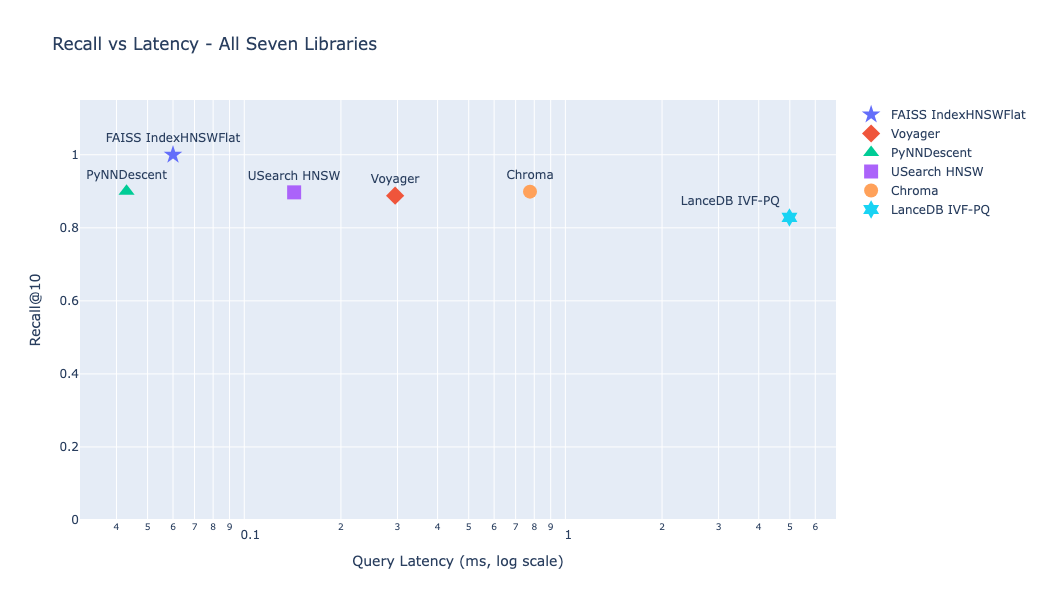

In [15]:
df_all = pd.DataFrame(all_results)

# Exclude sklearn from chart - its latency is so high it compresses everything else
df_chart = df_all[df_all["Library"] != "Sklearn brute force"].copy()

symbols = {
    "FAISS IndexHNSWFlat": "star",
    "Voyager":             "diamond",
    "PyNNDescent":         "triangle-up",
    "USearch HNSW":        "square",
    "Chroma":              "circle",
    "LanceDB IVF-PQ":      "hexagram",
}

fig = go.Figure()

for _, row in df_chart.iterrows():
    label_pos = "top left" if row["Library"] == "LanceDB IVF-PQ" else "top center"
    fig.add_trace(go.Scatter(
        x = [row["Latency"]],
        y = [row["Recall"]],
        mode = "markers+text",
        name = row["Library"],
        text = [row["Library"]],
        textposition = label_pos,
        marker = {"size": 14, "symbol": symbols.get(row["Library"], "circle")},
    ))

fig.update_layout(
    title = "Recall vs Latency - All Seven Libraries",
    xaxis_title = "Query Latency (ms, log scale)",
    yaxis_title = "Recall@10",
    xaxis_type = "log",
    yaxis = {"range": [0, 1.15]},
    width = 950,
    height = 600,
    showlegend = True,
    margin = {"r": 120},
)
fig.show()

## 11. What You Would Hit in Production

LanceDB's disk-based storage means query latency includes I/O - expect higher latency than in-memory libraries on the same hardware, especially for the first query after a cold start. Subsequent queries benefit from the OS page cache.

The IVF-PQ index trades recall for storage efficiency. With `num_sub_vectors=96` on 384-dimensional vectors, each vector is compressed to 96 bytes from 1,536 bytes - an 16x reduction. This is what enables LanceDB to handle datasets that would require hundreds of GB of RAM in FAISS.

LanceDB supports S3, GCS and Azure Blob Storage as backends with no code changes - swap the local path for a cloud URI and the rest of the code is identical. This is its clearest production advantage over every other library in this book.

## 12. When to Look Elsewhere

LanceDB is the wrong choice if:

- You need the highest recall - IVF-PQ compression loses information; use FAISS or PyNNDescent for maximum accuracy
- Your dataset fits comfortably in RAM and latency is critical - in-memory HNSW libraries are faster
- You need concurrent writes from multiple processes - LanceDB handles this but requires careful conflict resolution
- You want the simplest possible setup - FAISS or PyNNDescent are far simpler to get started with